In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.datasets import make_classification
from sklearn.utils import resample
from collections import Counter

In [1]:
!pip install collections

ERROR: Could not find a version that satisfies the requirement collections (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for collections


In [4]:
x,y =make_classification(n_classes=2, class_sep=2,weights=[0.9,0.1],n_informative=3,n_redundant=0,
                         n_features=5,n_samples=1000,random_state=42)

Original Class Distribution Counter({np.int64(0): 894, np.int64(1): 106})


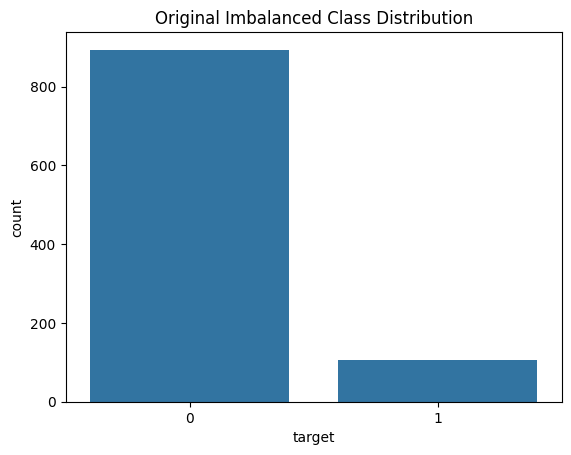

In [7]:
df=pd.DataFrame(x, columns=[f"feature_{i}" for i in range(x.shape[1])])
df['target']=y
print("Original Class Distribution",Counter(y))
sns.countplot(x=df['target'])
plt.title("Original Imbalanced Class Distribution")
plt.show()

In [8]:
df_majority=df[df['target']==0] 

In [13]:
df_minority =df[df['target']==1]

df_minority_oversampled = resample(df_minority, replace = True , n_samples=len(df_majority),                                    
                            random_state=42)

df_over = pd.concat([df_majority,df_minority_oversampled])
print("After oversampling:",Counter(df_over['target']))

After oversampling: Counter({0: 894, 1: 894})


In [14]:
df_majority_undersampled = resample(df_majority ,replace= False , n_samples=len(df_minority),random_state=42)
df_under = pd.concat([df_majority_undersampled,df_minority])
print("After undersampling :",Counter(df_under['target']))

After undersampling : Counter({0: 106, 1: 106})


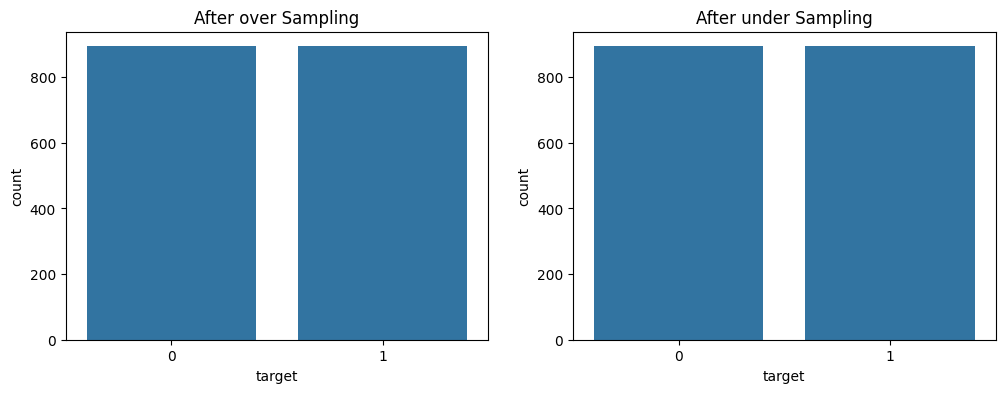

In [16]:
fig, axes = plt.subplots(1,2, figsize = (12,4))
sns.countplot(x=df_over['target'] , ax =axes[0])
axes[0].set_title("After over Sampling")

sns.countplot(x=df_over['target'] , ax =axes[1])
axes[1].set_title("After under Sampling")

plt.show()

